In [10]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [11]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [12]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [13]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [14]:
param_grid = {
    'model_params.hidden_layers': [(512, 128, 128, 128, 64), (256, 128, 128, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.1],
    'learning_rate': [0.00001, 0.0001],
    'batch_size': [64, 128],
    'epochs': [2000]
}


In [15]:
feature_df.fillna(-1, inplace=True)

In [16]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [17]:
feature_df.shape

(2660, 2729)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(512, 128, 128, 128, 64), (256, 128, 128, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0.1], 'learning_rate': [1e-05, 0.0001], 'batch_size': [64, 128], 'epochs': [2000]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


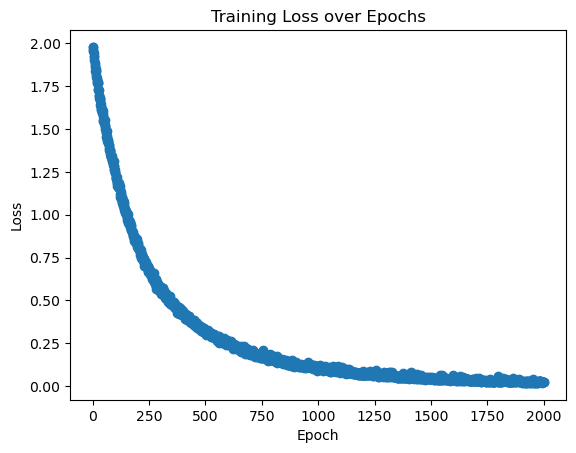

Final training loss: 0.026425509039023166
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


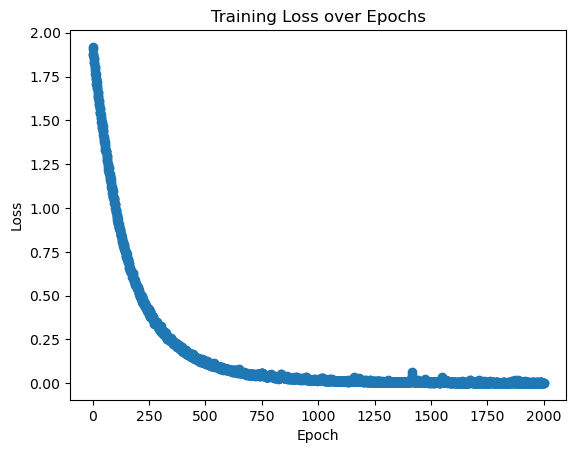

Final training loss: 0.0022682546110436284
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


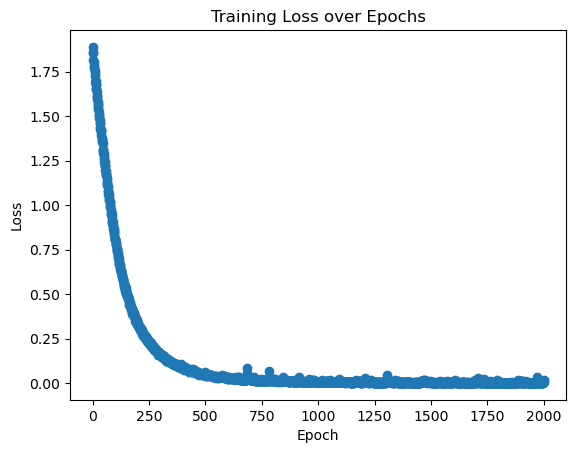

Final training loss: 0.00624112032237949
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


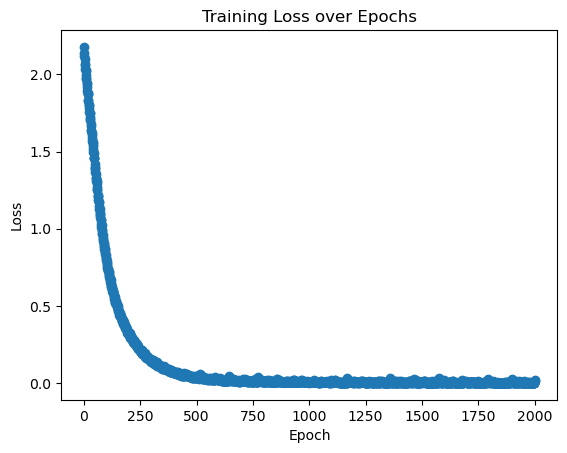

Final training loss: 0.019844850924689985
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


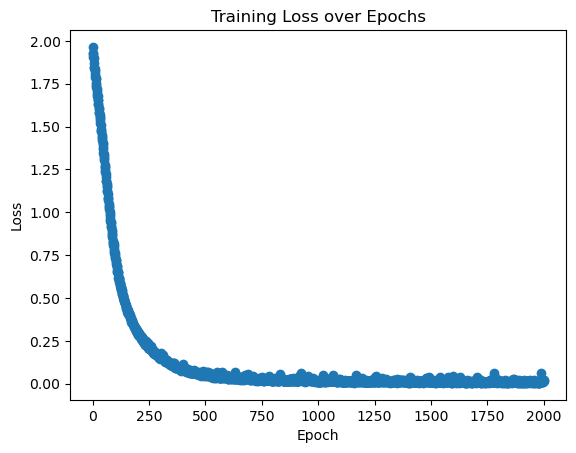

Final training loss: 0.01683904240304665
[TorchWrapper] Using device: mps


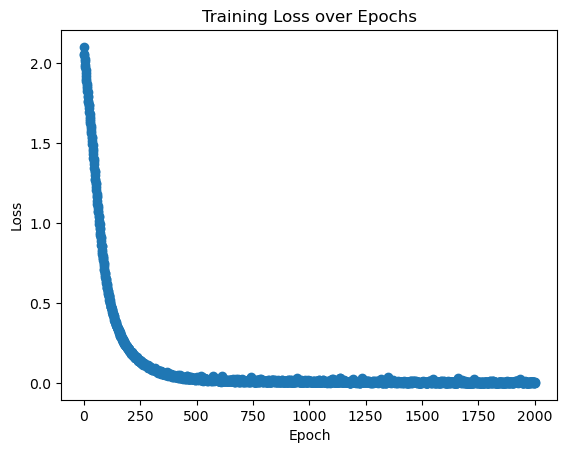

Final training loss: 0.0011635224242307987
{'home_goals_train_accuracy': 0.999874686716792, 'home_goals_train_precision': 0.9999443052074632, 'home_goals_valid_accuracy': 0.26867167919799495, 'home_goals_valid_precision': 0.15920285727487368, 'home_goals_test_accuracy': 0.2781954887218045, 'home_goals_test_precision': 0.16819377775325337, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.999874686716792, 'home_goals_train_gt_1_accuracy_std': 0.0002506265664160345, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 0.999874686716792, 'home_goals_train_gt_2_accuracy_std': 0.0002506265664160345, 'home_goals

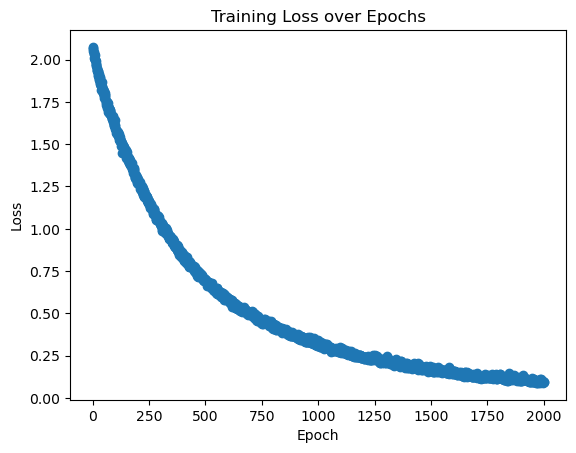

Final training loss: 0.0977368592319632
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


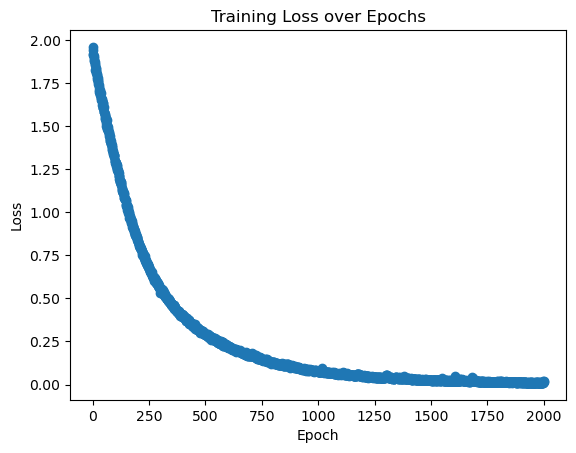

Final training loss: 0.014817221650391593
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


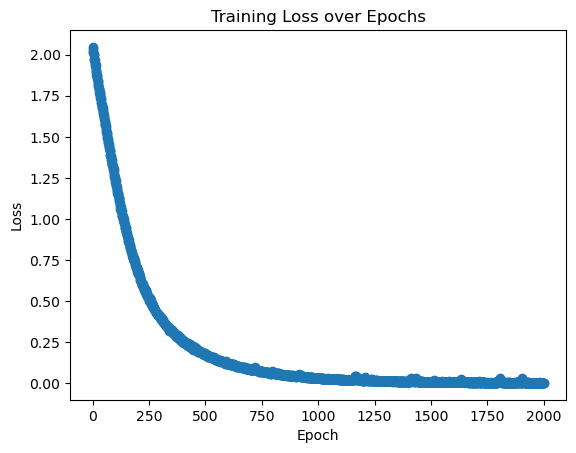

Final training loss: 0.0027883330028606835
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


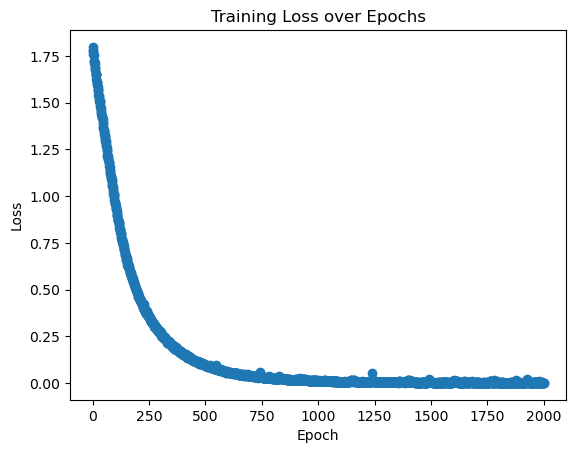

Final training loss: 0.0021125421740282747
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


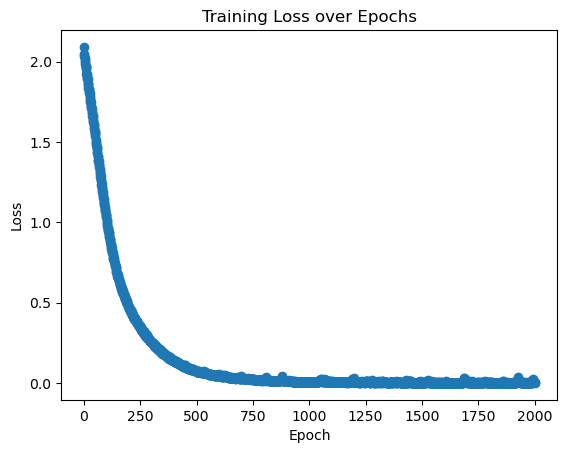

Final training loss: 0.0036098571730553545
[TorchWrapper] Using device: mps


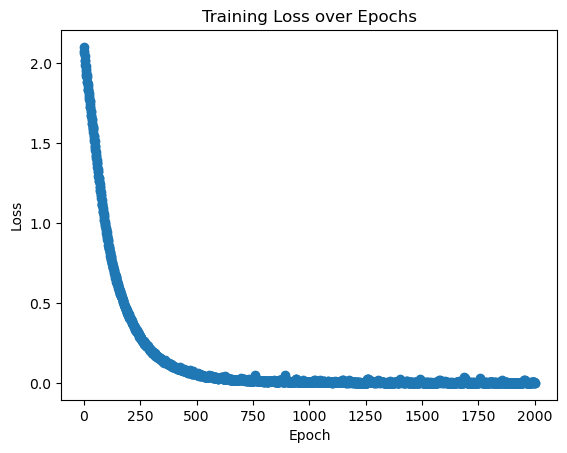

Final training loss: 0.0027641216262828
{'home_goals_train_accuracy': 0.999749373433584, 'home_goals_train_precision': 0.9998447204968943, 'home_goals_valid_accuracy': 0.2681704260651629, 'home_goals_valid_precision': 0.16994529704582634, 'home_goals_test_accuracy': 0.30451127819548873, 'home_goals_test_precision': 0.1606865831553765, 'home_goals_train_lte_0_accuracy': 0.999749373433584, 'home_goals_train_lte_0_accuracy_std': 0.000501253132832069, 'home_goals_train_lte_0_precision': 0.9989130434782609, 'home_goals_train_lte_0_precision_std': 0.0021739130434782704, 'home_goals_train_gt_0_accuracy': 0.999749373433584, 'home_goals_train_gt_0_accuracy_std': 0.000501253132832069, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.999749373433584, 'home_goals_train_gt_1_accuracy_std': 0.000501253132832069, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 0

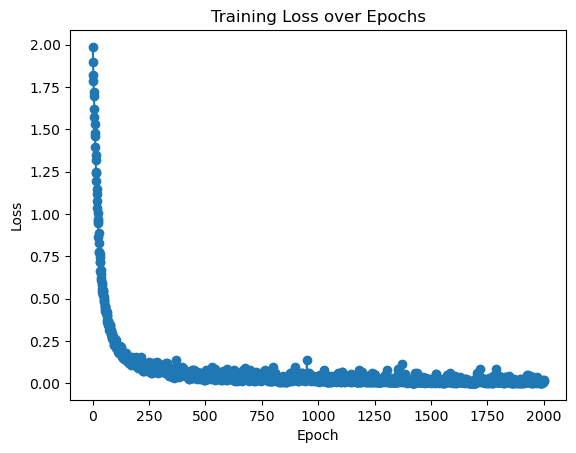

Final training loss: 0.018352853549751722
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


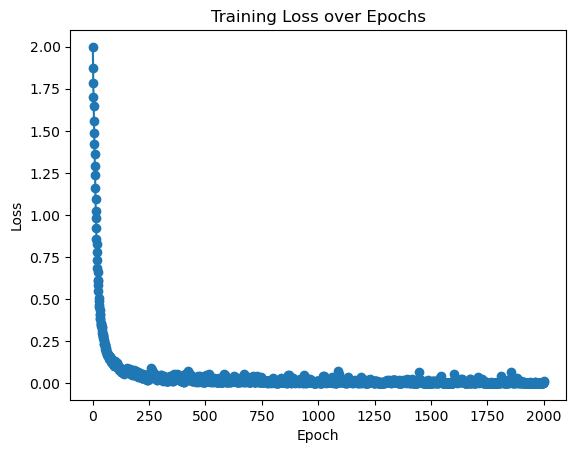

Final training loss: 0.010155657797650361
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


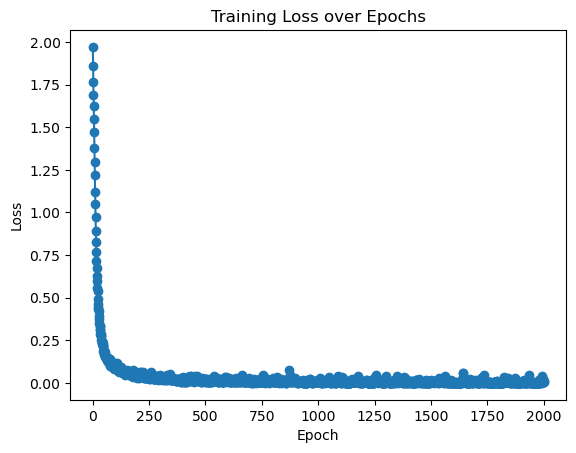

Final training loss: 0.007582408142623895
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


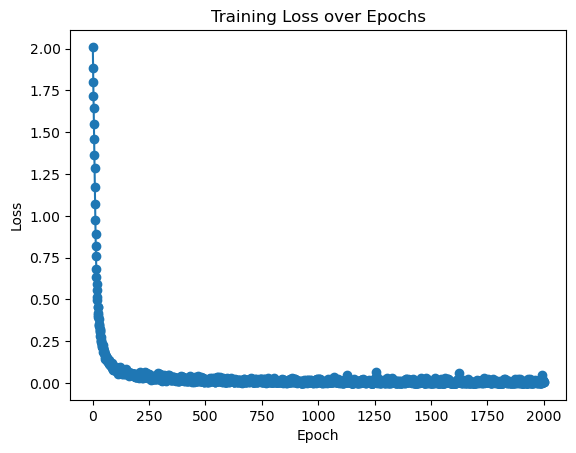

Final training loss: 0.00677124955087438
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


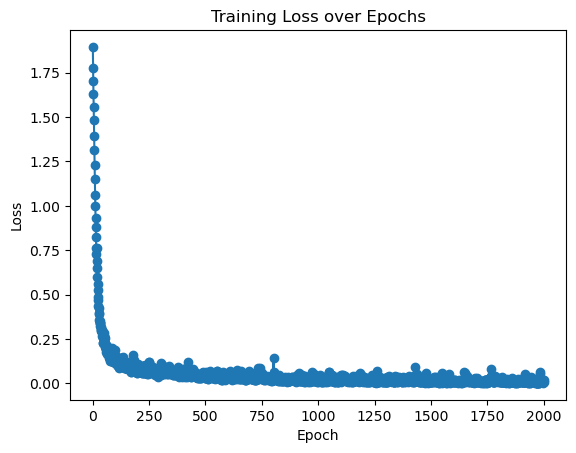

Final training loss: 0.017933254595845938
[TorchWrapper] Using device: mps


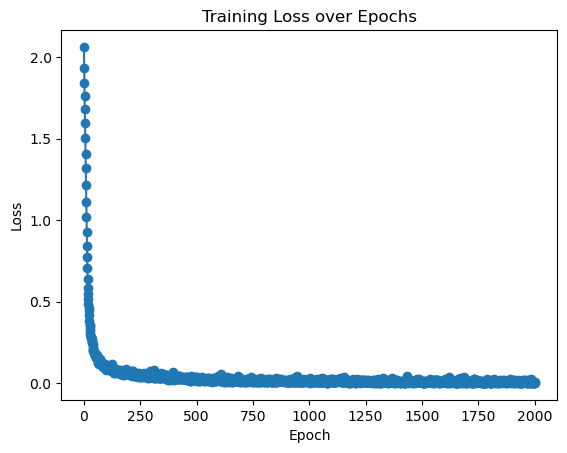

Final training loss: 0.0035618014673335957
{'home_goals_train_accuracy': 0.999749373433584, 'home_goals_train_precision': 0.9997113997113998, 'home_goals_valid_accuracy': 0.2601503759398496, 'home_goals_valid_precision': 0.1636407051741208, 'home_goals_test_accuracy': 0.2819548872180451, 'home_goals_test_precision': 0.17751437275246798, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.999749373433584, 'home_goals_train_gt_1_accuracy_std': 0.000501253132832069, 'home_goals_train_gt_1_precision': 0.9994520547945205, 'home_goals_train_gt_1_precision_std': 0.0010958904109588997, 'home_goals_train_gt_2_accuracy': 0.999749373433584, 'home_goals_train_gt_2_accuracy_std': 0.00

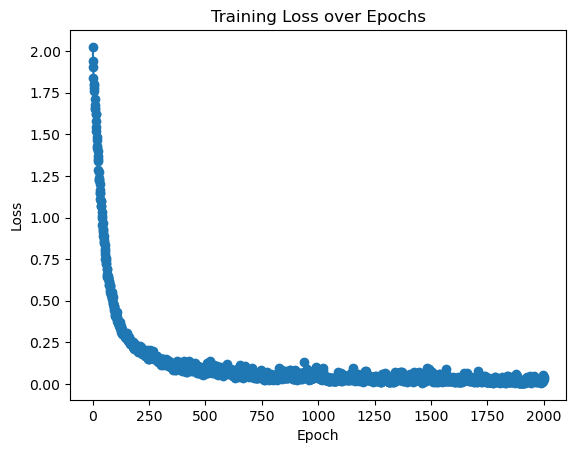

Final training loss: 0.02705239008804013
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


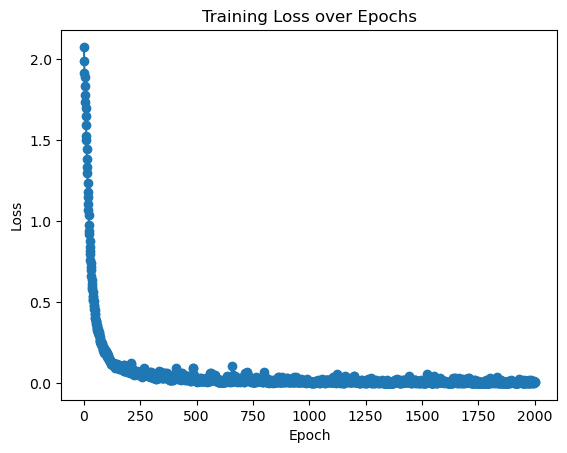

Final training loss: 0.006873250913276409
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


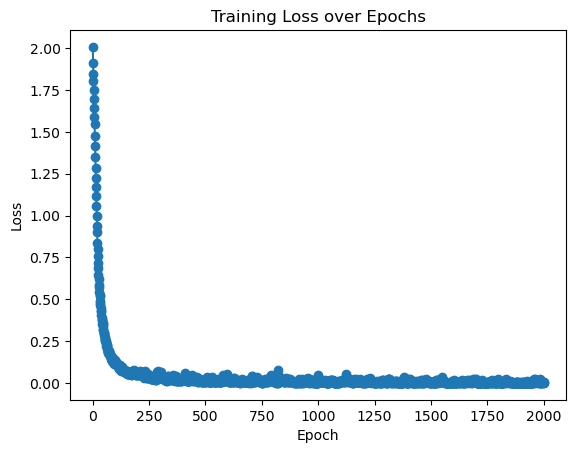

Final training loss: 0.00848983917867729
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


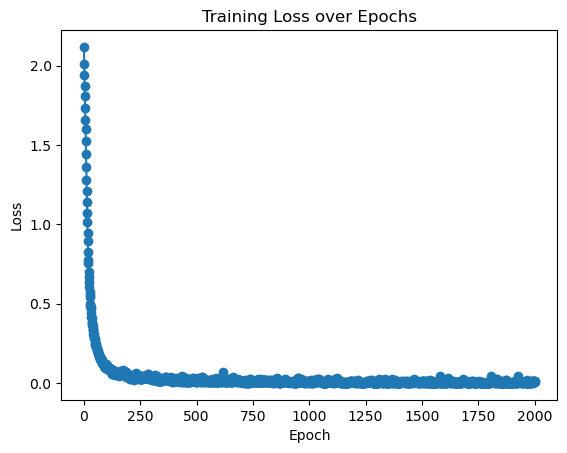

Final training loss: 0.005410069786479001
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


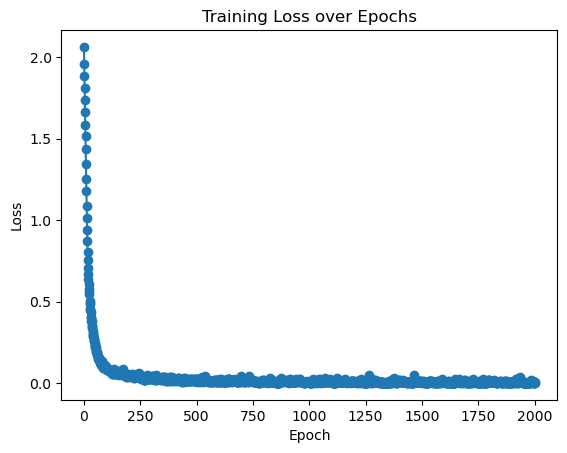

Final training loss: 0.0031160126129786176
[TorchWrapper] Using device: mps


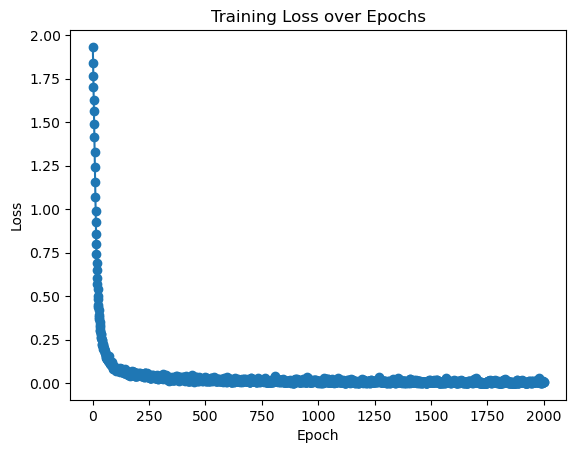

Final training loss: 0.007422469422507505
{'home_goals_train_accuracy': 0.9989974937343359, 'home_goals_train_precision': 0.9991465980827684, 'home_goals_valid_accuracy': 0.2521303258145363, 'home_goals_valid_precision': 0.16142415015536243, 'home_goals_test_accuracy': 0.2932330827067669, 'home_goals_test_precision': 0.16541206724149546, 'home_goals_train_lte_0_accuracy': 0.9994987468671679, 'home_goals_train_lte_0_accuracy_std': 0.0010025062656641825, 'home_goals_train_lte_0_precision': 0.997872340425532, 'home_goals_train_lte_0_precision_std': 0.004255319148936155, 'home_goals_train_gt_0_accuracy': 0.9994987468671679, 'home_goals_train_gt_0_accuracy_std': 0.0010025062656641825, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.9994987468671679, 'home_goals_train_gt_1_accuracy_std': 0.0010025062656641825, 'home_goals_train_gt_1_precision': 0.9989130434782609, 'home_goals_train_gt_1_precision_std': 0.0021739130434782

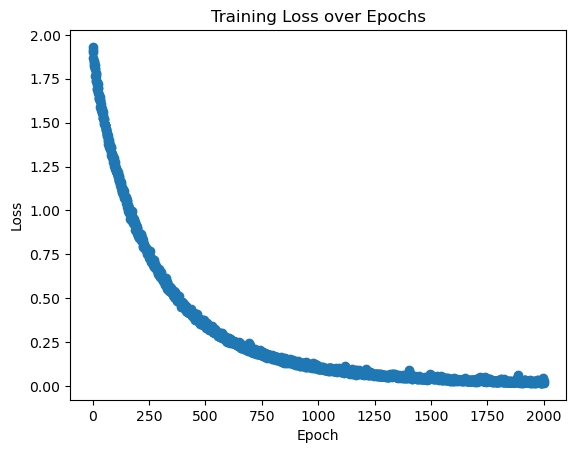

Final training loss: 0.019791801919913234
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


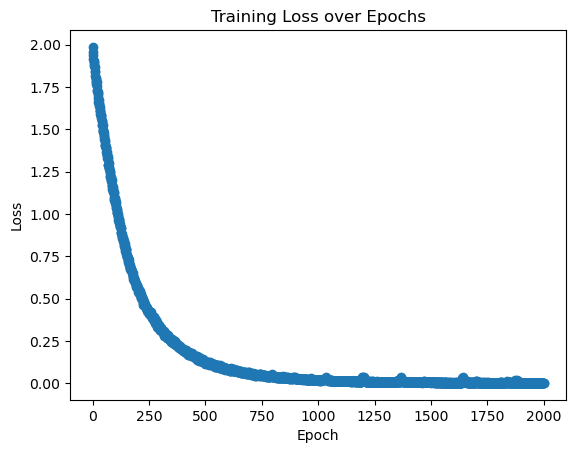

Final training loss: 0.0014803016623645498
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


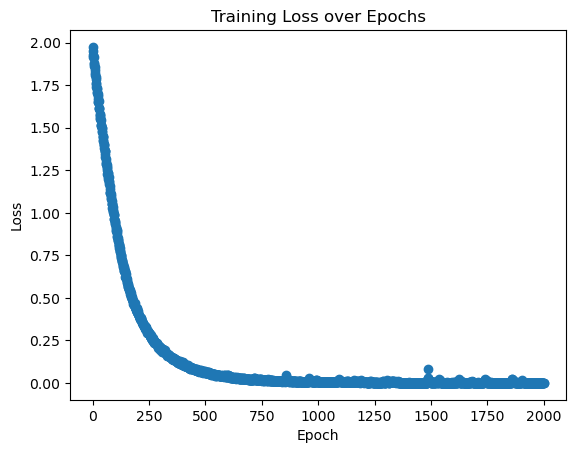

Final training loss: 0.0010550481929780672
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


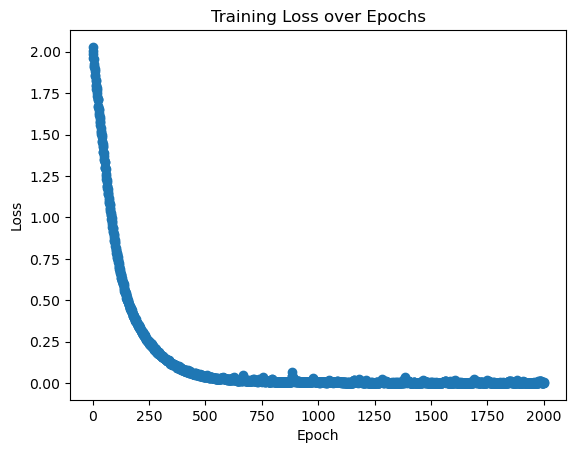

Final training loss: 0.0063248179070441455
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


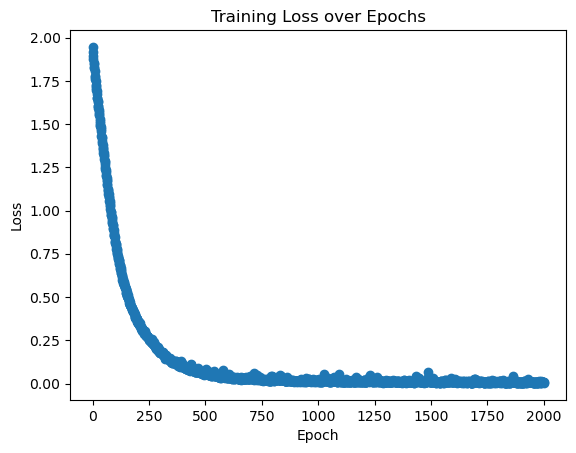

Final training loss: 0.00517949905984085
[TorchWrapper] Using device: mps


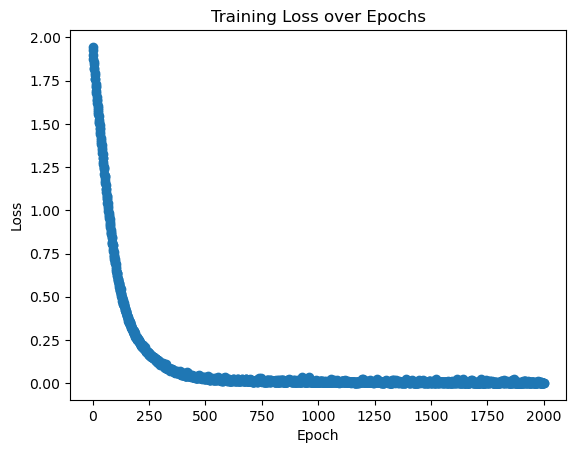

Final training loss: 0.0019152879064518308
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.26516290726817043, 'home_goals_valid_precision': 0.15690451113707088, 'home_goals_test_accuracy': 0.2744360902255639, 'home_goals_test_precision': 0.15107183737861818, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt

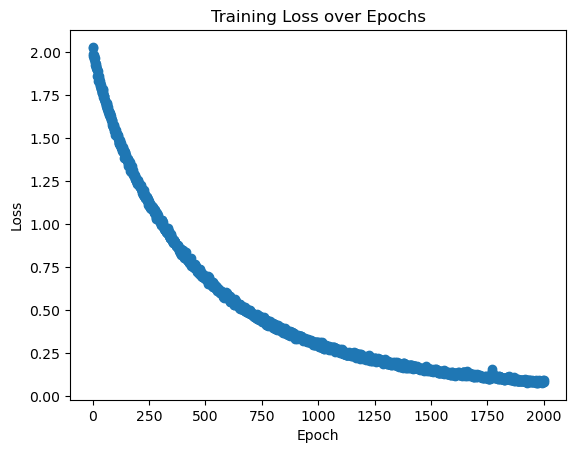

Final training loss: 0.08369464935141996
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


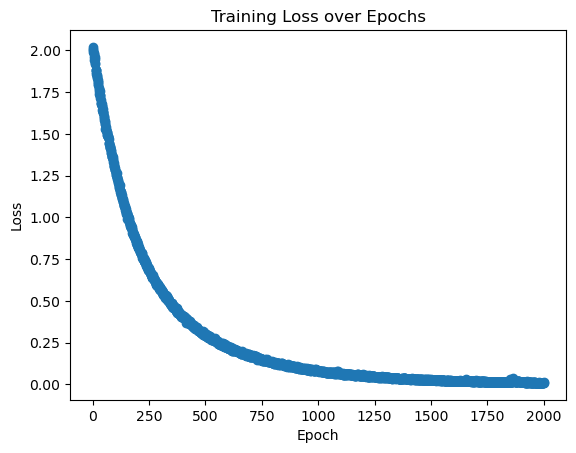

Final training loss: 0.014176638054668456
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


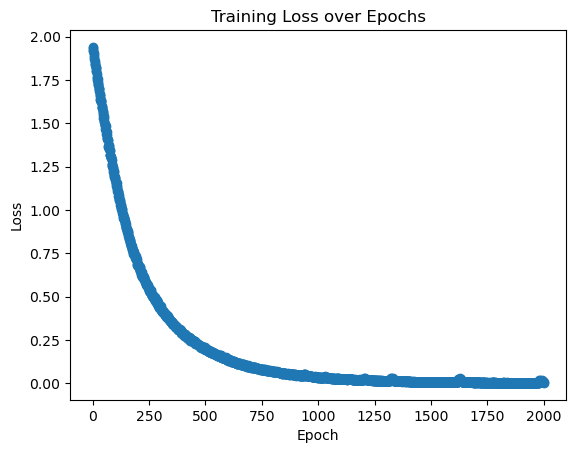

Final training loss: 0.0043011597286109985
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


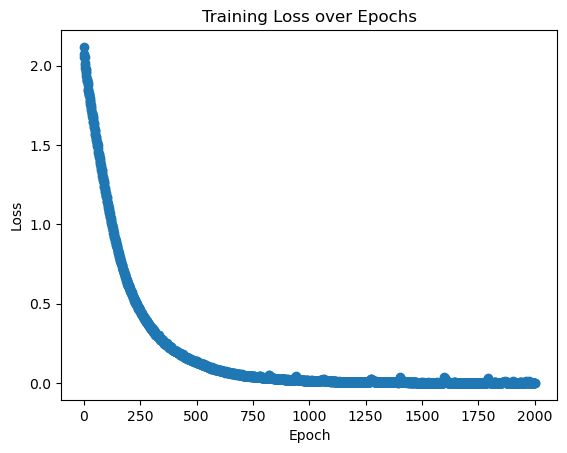

Final training loss: 0.00111241030149666
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


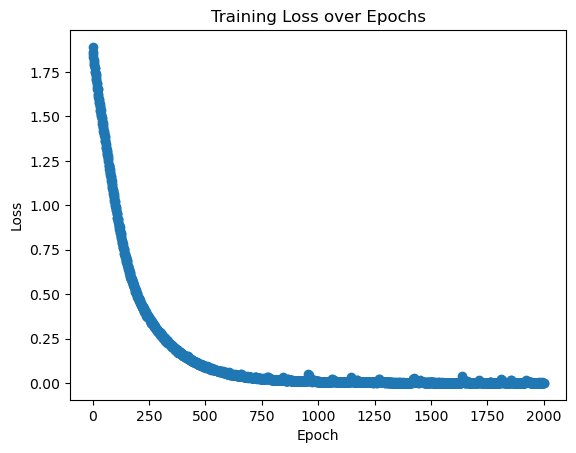

Final training loss: 0.00208801035740107
[TorchWrapper] Using device: mps


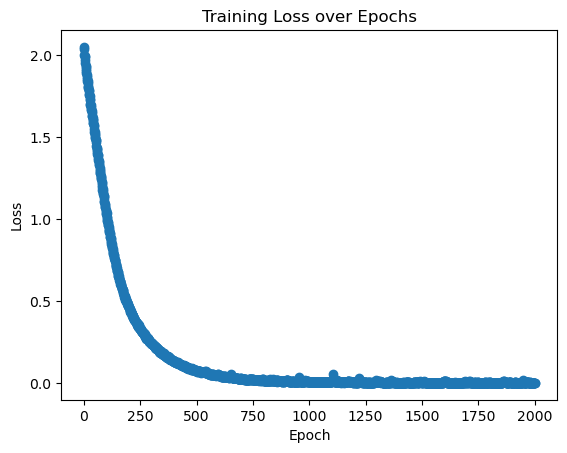

Final training loss: 0.0012195032190511262
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2641604010025062, 'home_goals_valid_precision': 0.14870409527352085, 'home_goals_test_accuracy': 0.2706766917293233, 'home_goals_test_precision': 0.14991934214016803, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_

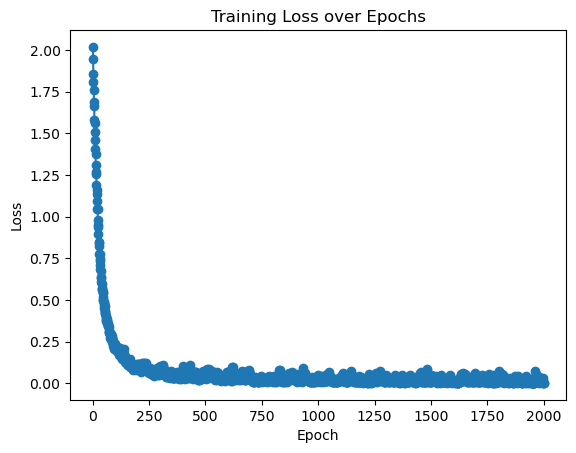

Final training loss: 0.0023295350494166663
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


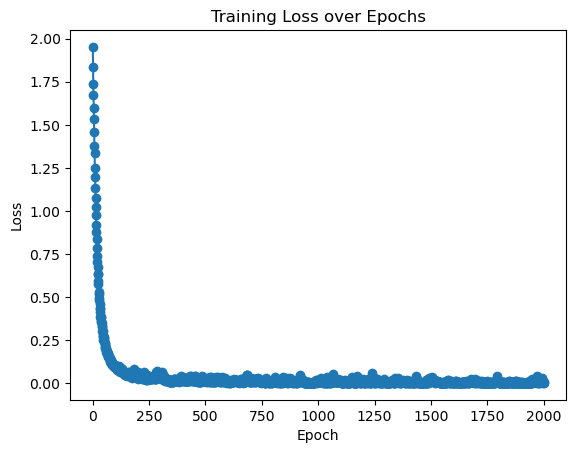

Final training loss: 0.005518886657492409
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


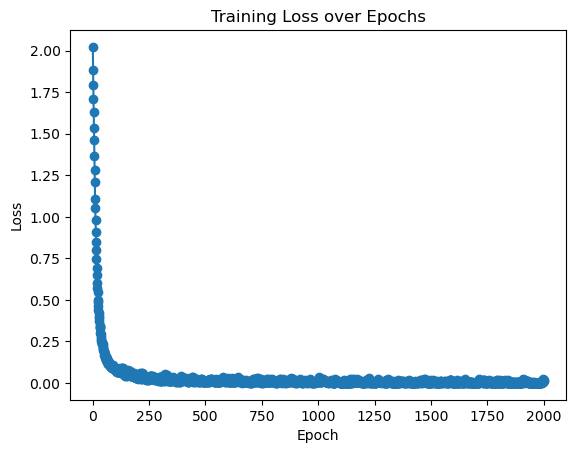

Final training loss: 0.019679629257137118
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


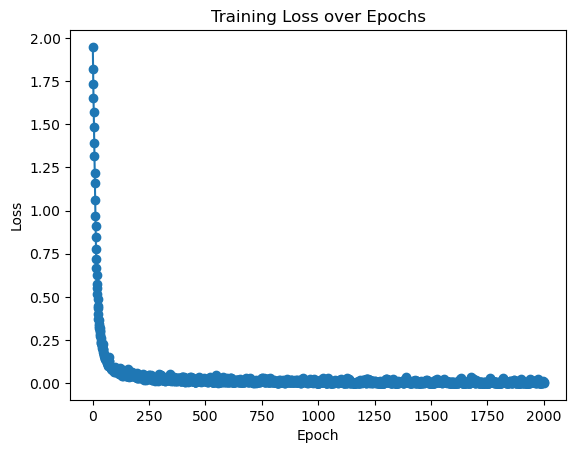

Final training loss: 0.0015434457968341601
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


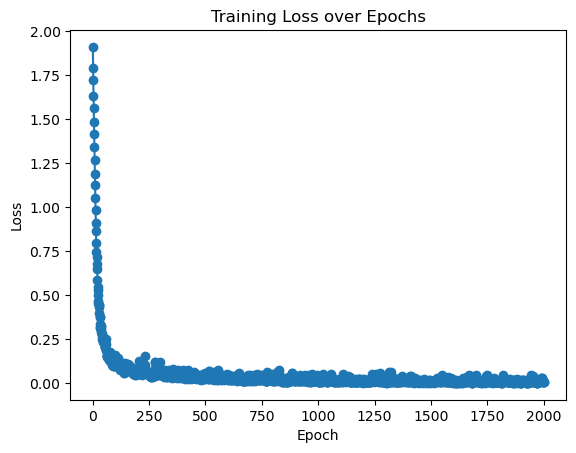

Final training loss: 0.009005162554949448
[TorchWrapper] Using device: mps


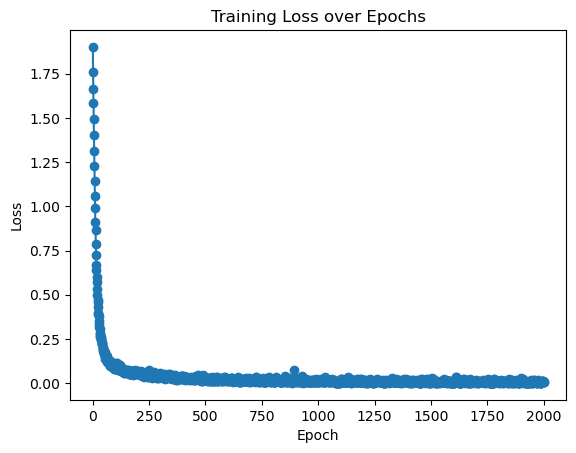

Final training loss: 0.006280134277964445
{'home_goals_train_accuracy': 0.9998997493734336, 'home_goals_train_precision': 0.9999403519236505, 'home_goals_valid_accuracy': 0.24661654135338346, 'home_goals_valid_precision': 0.15957191004011145, 'home_goals_test_accuracy': 0.30451127819548873, 'home_goals_test_precision': 0.180449331213338, 'home_goals_train_lte_0_accuracy': 0.9998997493734336, 'home_goals_train_lte_0_accuracy_std': 0.0002005012531328454, 'home_goals_train_lte_0_precision': 0.9995824634655532, 'home_goals_train_lte_0_precision_std': 0.0008350730688935215, 'home_goals_train_gt_0_accuracy': 0.9998997493734336, 'home_goals_train_gt_0_accuracy_std': 0.0002005012531328454, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.9998997493734336, 'home_goals_train_gt_1_accuracy_std': 0.0002005012531328454, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_acc

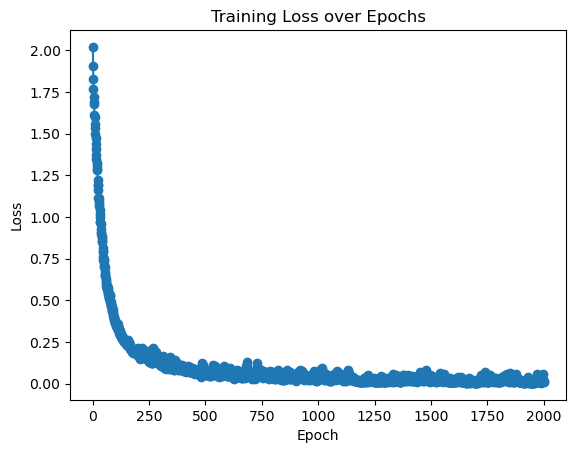

Final training loss: 0.009293617806712487
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


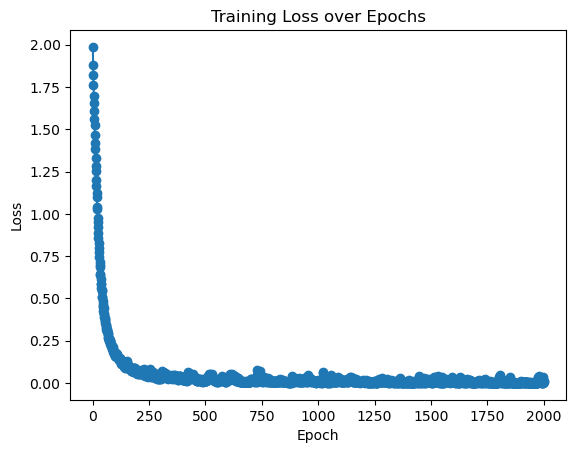

Final training loss: 0.006686552299331304
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


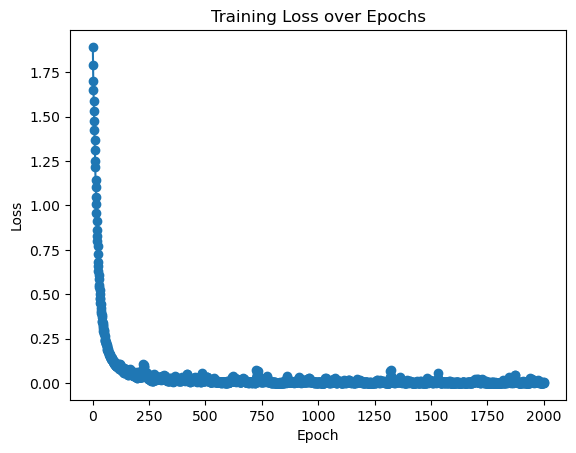

Final training loss: 0.0011432282542016235
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


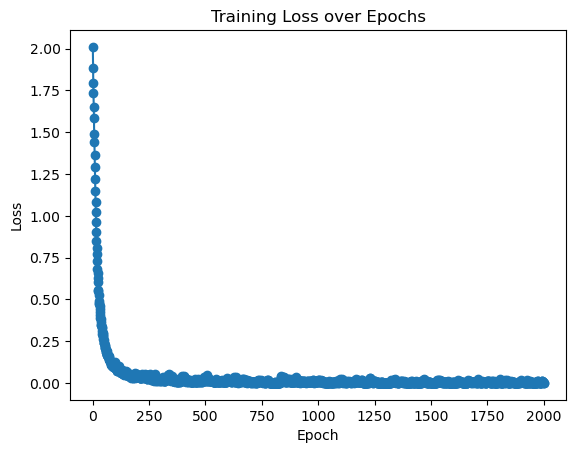

Final training loss: 0.00155532685835568
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


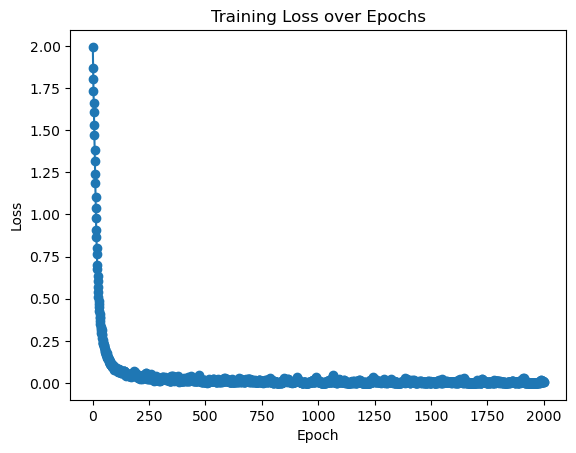

Final training loss: 0.0058555538837569195
[TorchWrapper] Using device: mps


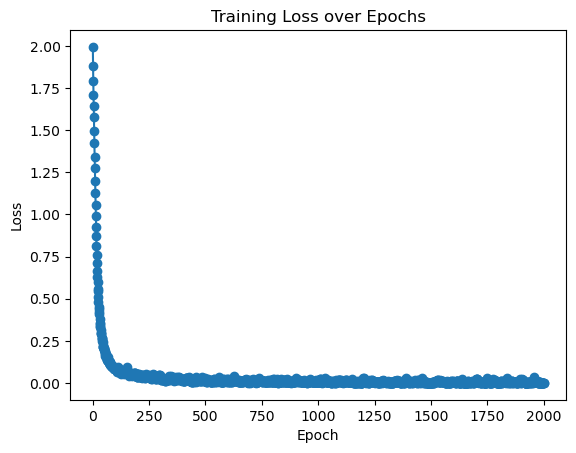

Final training loss: 0.0006975393566581496
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.25413533834586466, 'home_goals_valid_precision': 0.15795053131291603, 'home_goals_test_accuracy': 0.3007518796992481, 'home_goals_test_precision': 0.16827492517147694, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt

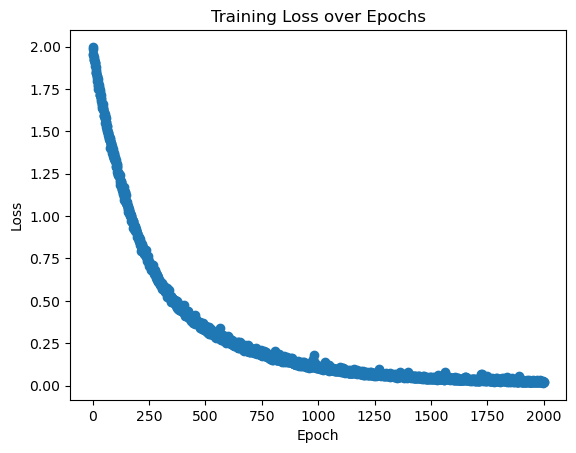

Final training loss: 0.022394464671014247
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


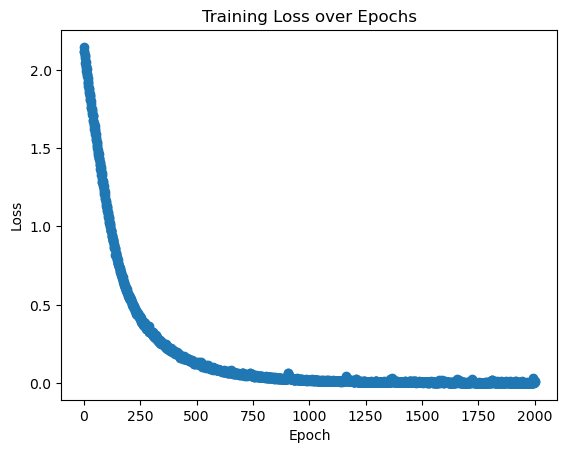

Final training loss: 0.006887103895421016
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


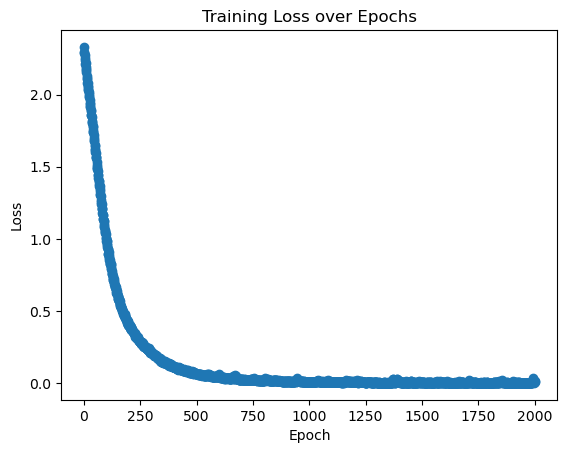

Final training loss: 0.012801684376549476
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


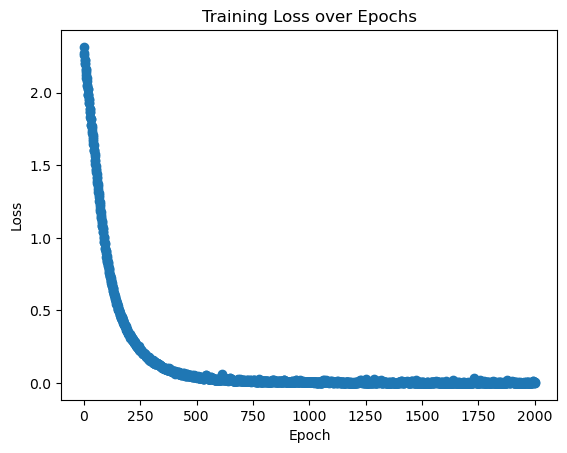

Final training loss: 0.003965170893387491
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


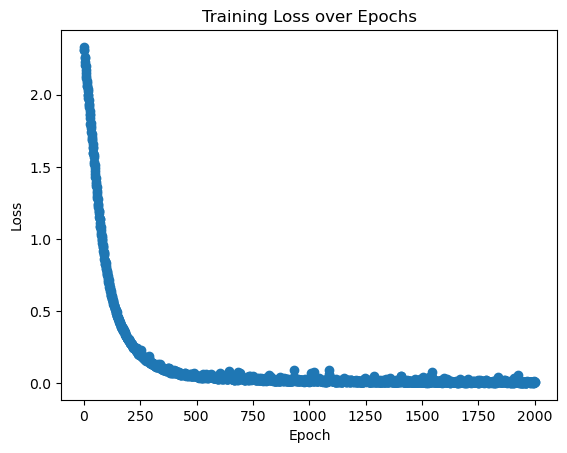

Final training loss: 0.012518839042325666
[TorchWrapper] Using device: mps


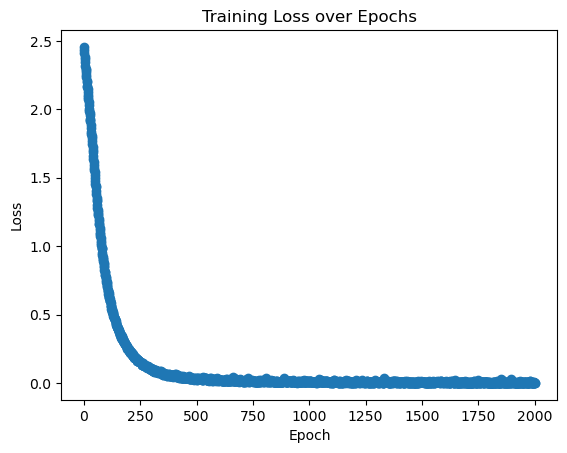

Final training loss: 0.004001346421391067
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.28872180451127816, 'away_goals_valid_precision': 0.16809257470705113, 'away_goals_test_accuracy': 0.2932330827067669, 'away_goals_test_precision': 0.14403241112489965, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_

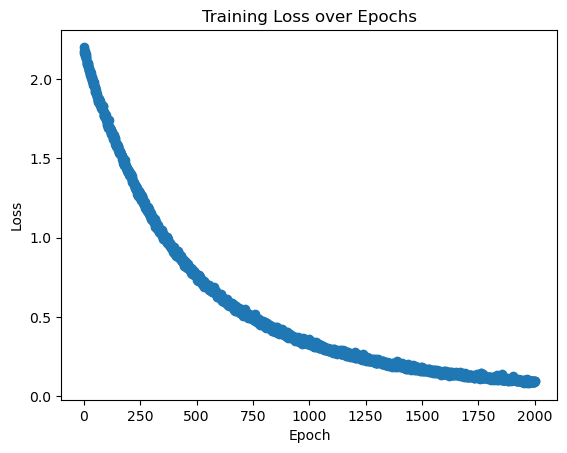

Final training loss: 0.09516100432340961
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


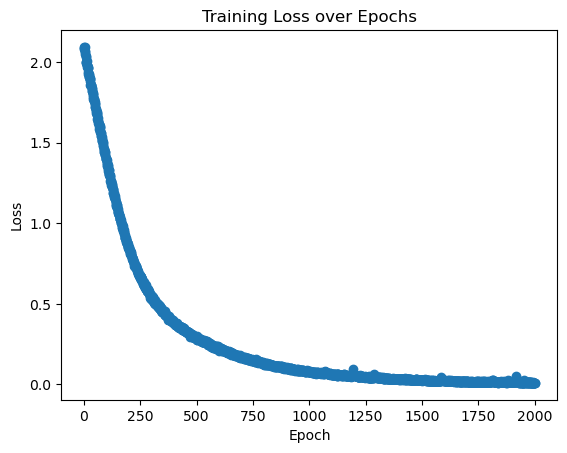

Final training loss: 0.010816973524359534
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


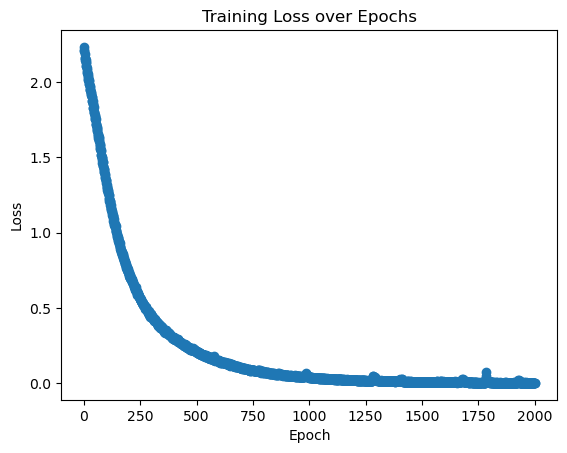

Final training loss: 0.003967098304114881
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


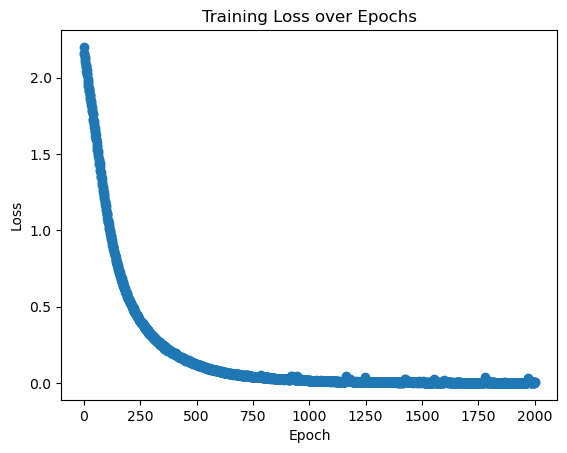

Final training loss: 0.007151229744707059
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


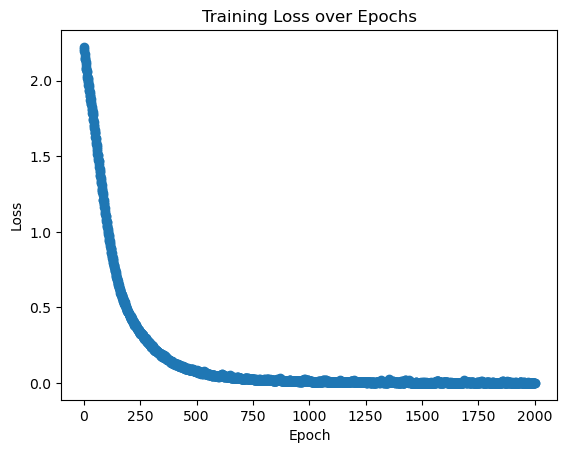

Final training loss: 0.001942680805354358
[TorchWrapper] Using device: mps


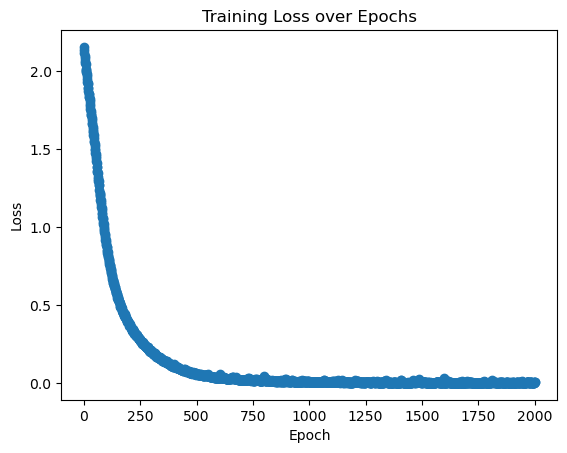

Final training loss: 0.005546552899648391
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.2842105263157894, 'away_goals_valid_precision': 0.13977729262098887, 'away_goals_test_accuracy': 0.2781954887218045, 'away_goals_test_precision': 0.148396509857184, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_3_a

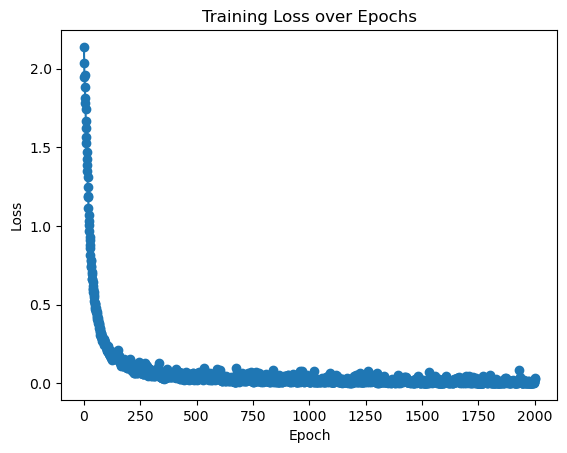

Final training loss: 0.02979186784130589
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


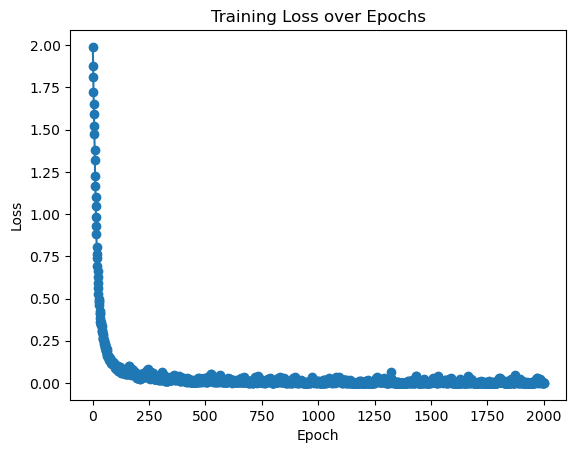

Final training loss: 0.0008930262874194508
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


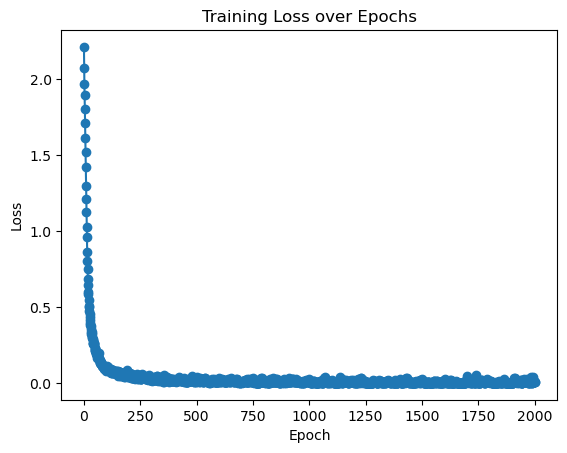

Final training loss: 0.006845378583420065
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


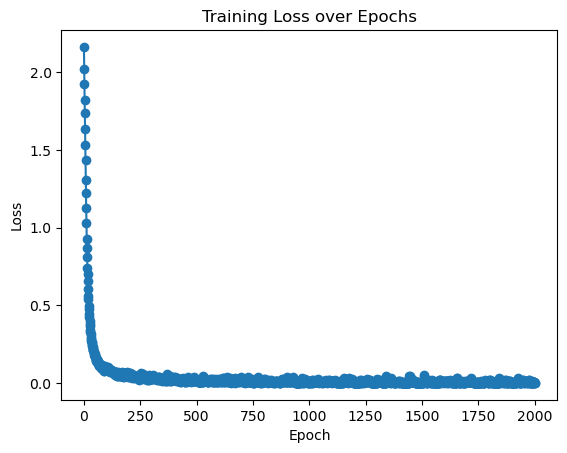

Final training loss: 0.0022259645819323218
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


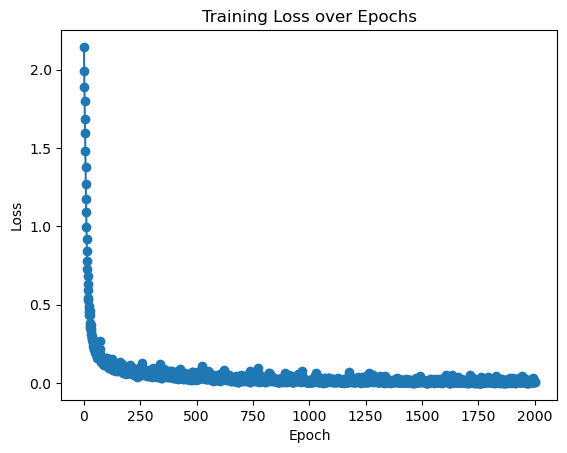

Final training loss: 0.00936370639639316
[TorchWrapper] Using device: mps


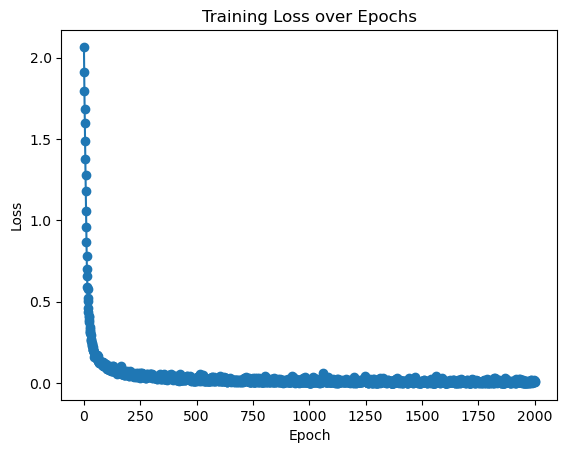

Final training loss: 0.007072332622086569
{'away_goals_train_accuracy': 0.9998997493734336, 'away_goals_train_precision': 0.9999620637329286, 'away_goals_valid_accuracy': 0.27819548872180444, 'away_goals_valid_precision': 0.17045910978592158, 'away_goals_test_accuracy': 0.2781954887218045, 'away_goals_test_precision': 0.13797806203821242, 'away_goals_train_lte_0_accuracy': 0.9998997493734336, 'away_goals_train_lte_0_accuracy_std': 0.0002005012531328454, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 0.9998997493734336, 'away_goals_train_gt_0_accuracy_std': 0.0002005012531328454, 'away_goals_train_gt_0_precision': 0.9998546511627907, 'away_goals_train_gt_0_precision_std': 0.00029069767441858296, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_

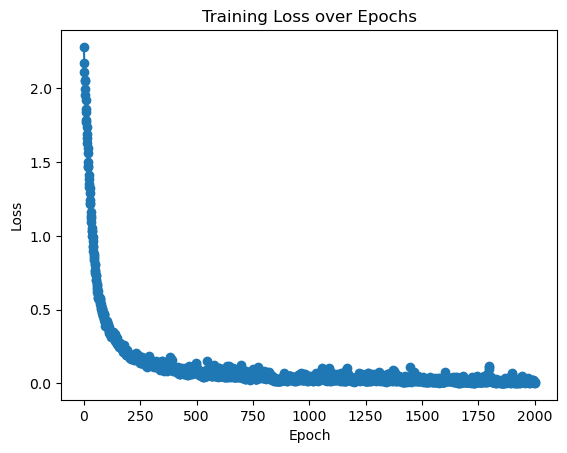

Final training loss: 0.005597853767020362
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


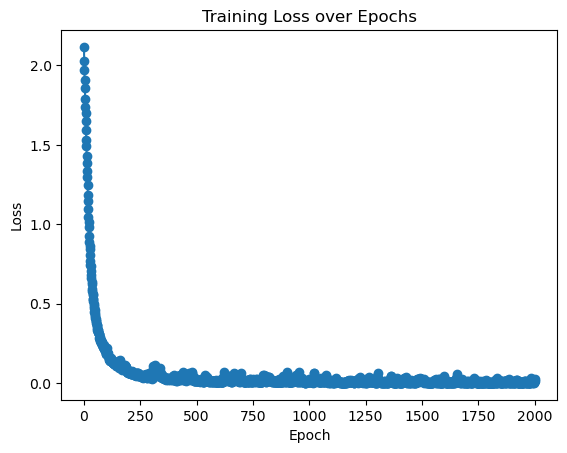

Final training loss: 0.011561636824655653
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


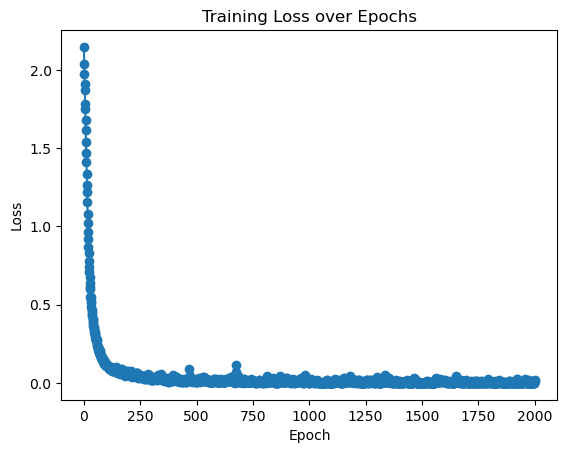

Final training loss: 0.011607707629825239
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


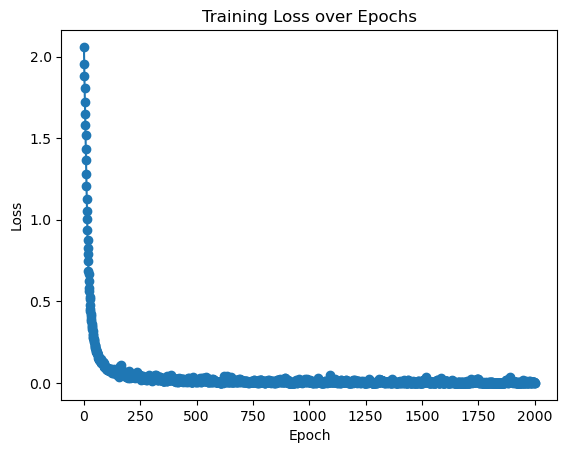

Final training loss: 0.0015014398359882652
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


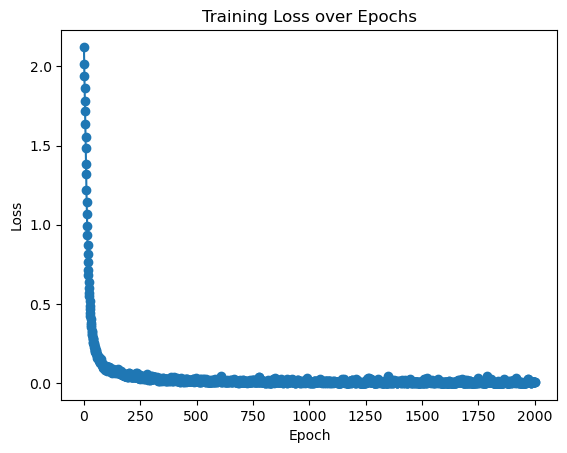

Final training loss: 0.004434972413276371
[TorchWrapper] Using device: mps


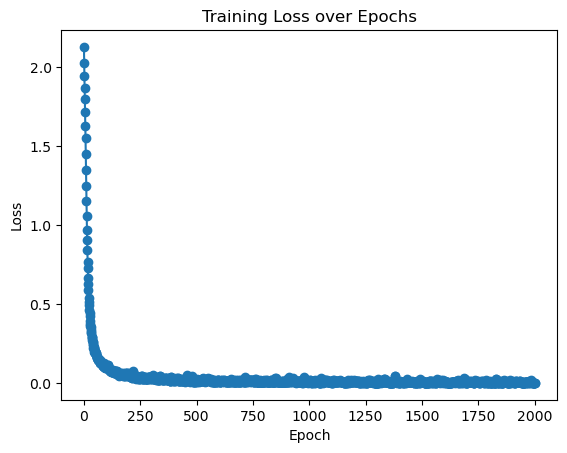

Final training loss: 0.0012755034629863577
{'away_goals_train_accuracy': 0.9988304093567251, 'away_goals_train_precision': 0.9995393990929706, 'away_goals_valid_accuracy': 0.28270676691729324, 'away_goals_valid_precision': 0.16680308486161458, 'away_goals_test_accuracy': 0.2894736842105263, 'away_goals_test_precision': 0.14101187033517862, 'away_goals_train_lte_0_accuracy': 0.9988304093567251, 'away_goals_train_lte_0_accuracy_std': 0.0019485219364562387, 'away_goals_train_lte_0_precision': 0.9968253968253968, 'away_goals_train_lte_0_precision_std': 0.006349206349206371, 'away_goals_train_gt_0_accuracy': 0.9988304093567251, 'away_goals_train_gt_0_accuracy_std': 0.0019485219364562387, 'away_goals_train_gt_0_precision': 0.9997572815533982, 'away_goals_train_gt_0_precision_std': 0.0004854368932039055, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_ac

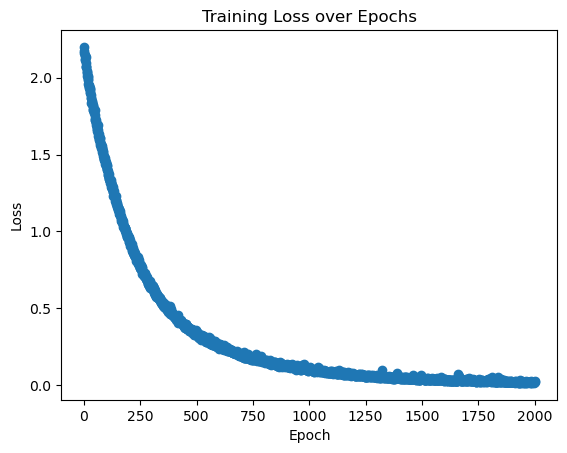

Final training loss: 0.02481788908479208
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


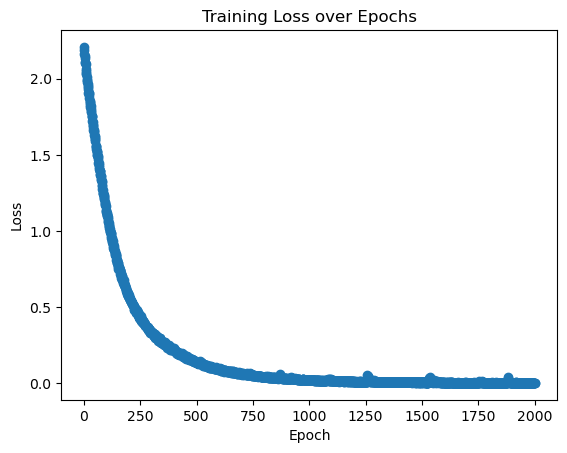

Final training loss: 0.0025776668112108807
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


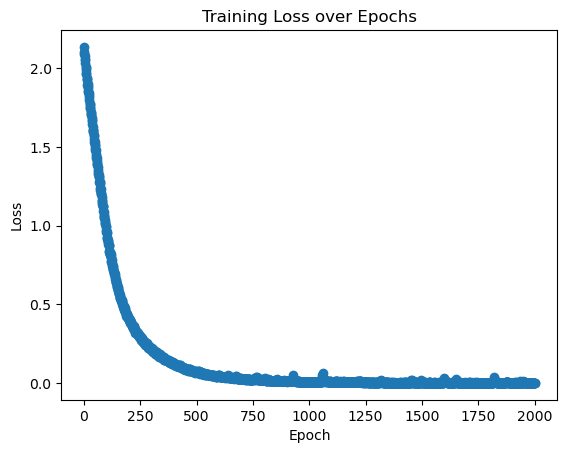

Final training loss: 0.0012081817977356824
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


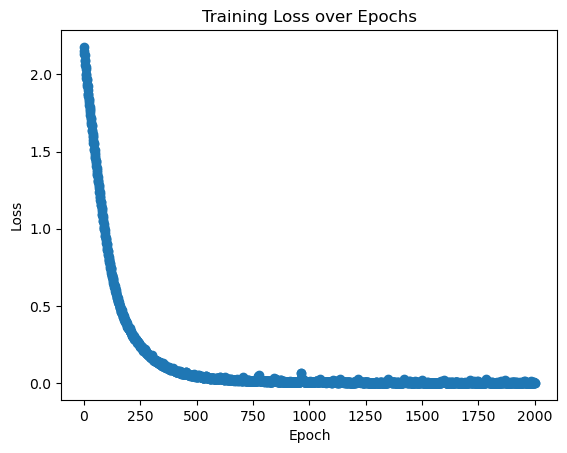

Final training loss: 0.001053799201388911
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


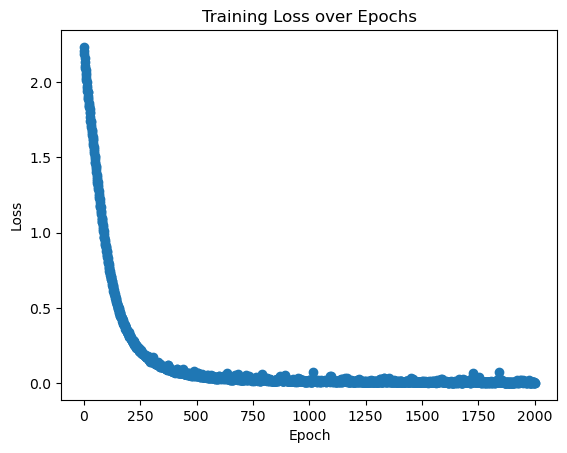

Final training loss: 0.0041803298877519475
[TorchWrapper] Using device: mps


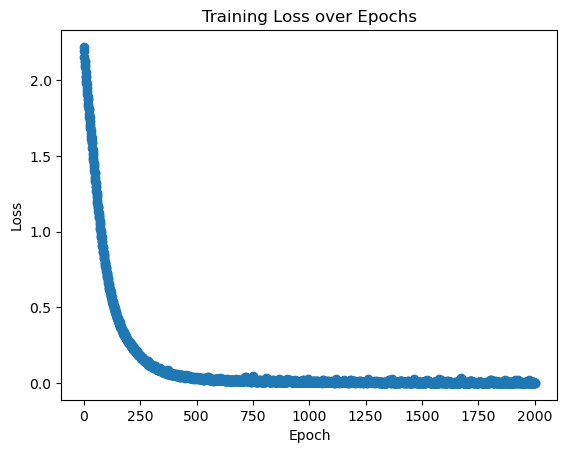

Final training loss: 0.0019834051294790687
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.2822055137844611, 'away_goals_valid_precision': 0.15018290437792703, 'away_goals_test_accuracy': 0.2669172932330827, 'away_goals_test_precision': 0.1327293341579056, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_3

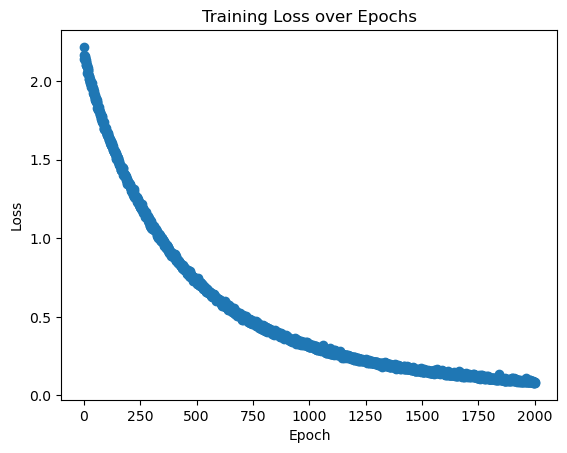

Final training loss: 0.08116589749890163
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


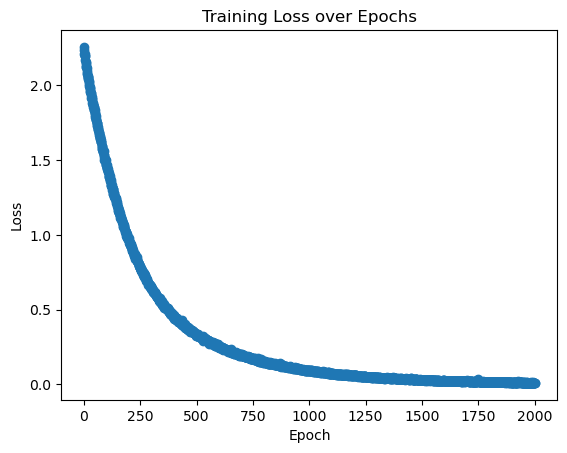

Final training loss: 0.009603663599748808
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


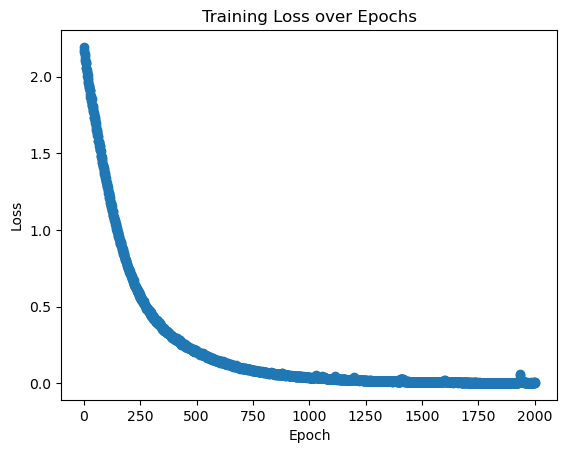

Final training loss: 0.005406260824199757
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


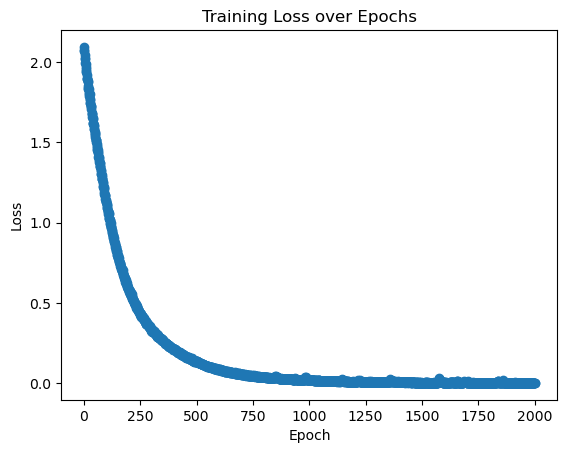

Final training loss: 0.0013125817131549866
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


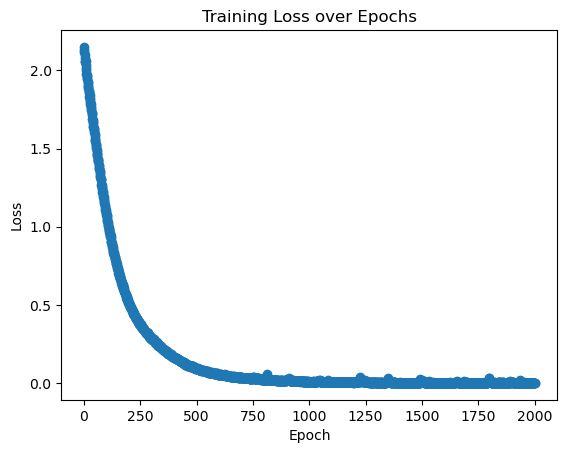

Final training loss: 0.001238564270919651
[TorchWrapper] Using device: mps


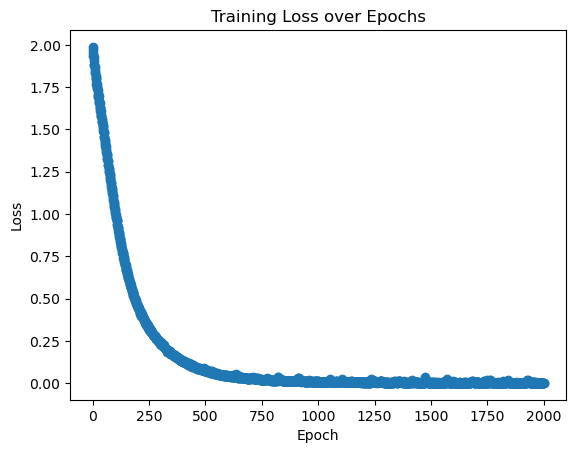

Final training loss: 0.0010582018725701617
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.2796992481203008, 'away_goals_valid_precision': 0.14195001018874695, 'away_goals_test_accuracy': 0.2744360902255639, 'away_goals_test_precision': 0.1367421711929215, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_3

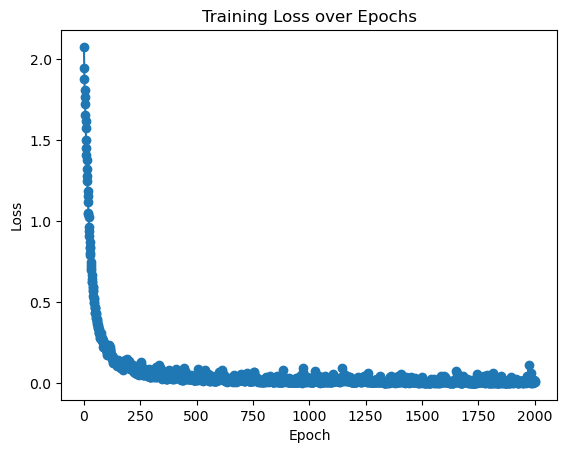

Final training loss: 0.009180886666278792
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


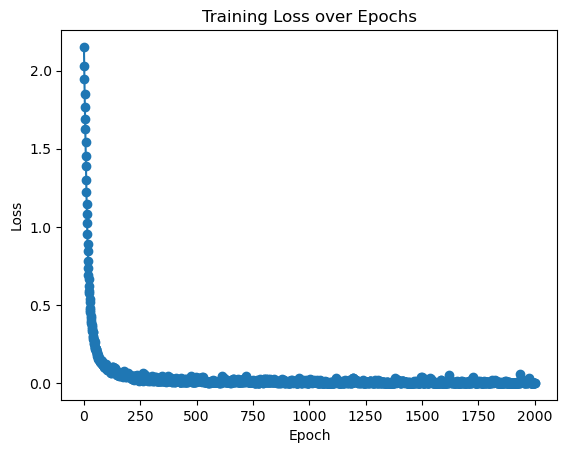

Final training loss: 0.0010923499639442465
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


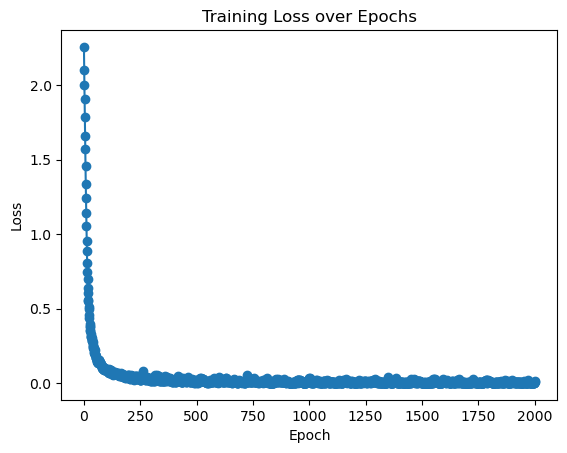

Final training loss: 0.013525121659254414
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


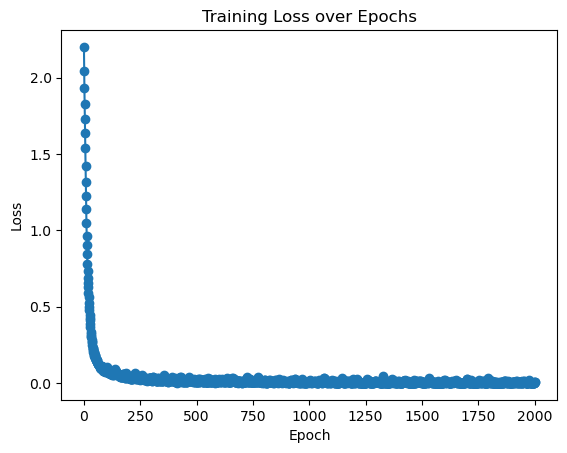

Final training loss: 0.006489001586362206
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


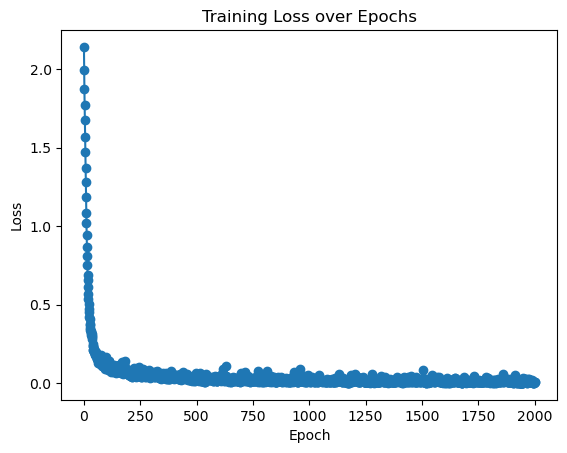

Final training loss: 0.006004251082215393
[TorchWrapper] Using device: mps


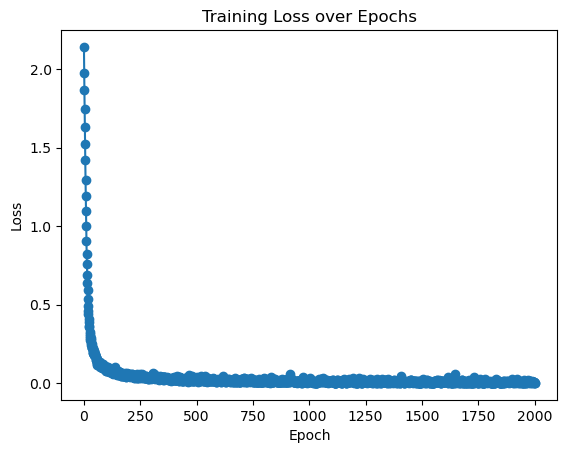

Final training loss: 0.0025746213148601675
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.2907268170426065, 'away_goals_valid_precision': 0.1494829487658725, 'away_goals_test_accuracy': 0.2894736842105263, 'away_goals_test_precision': 0.13875164690382083, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_3

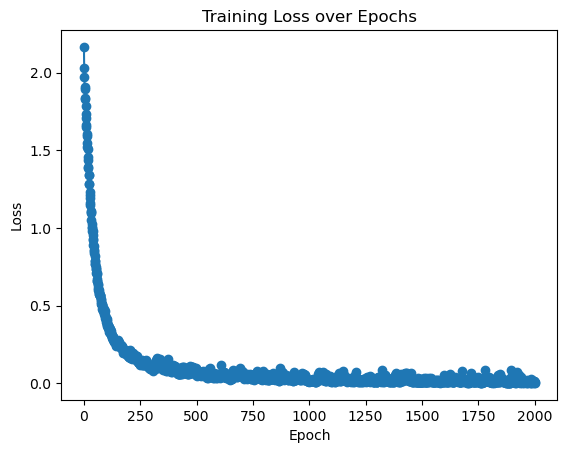

Final training loss: 0.006171788763544315
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


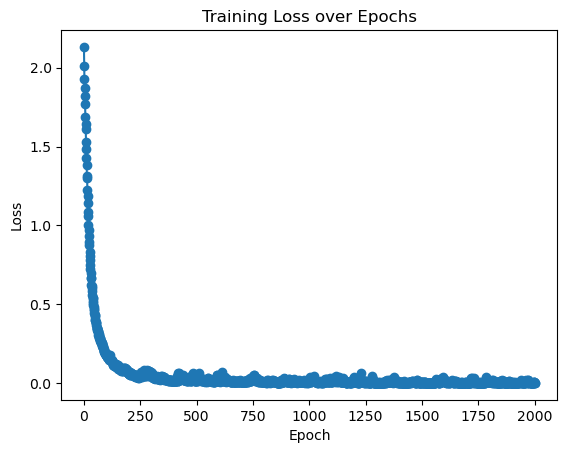

Final training loss: 0.0032244656654541615
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


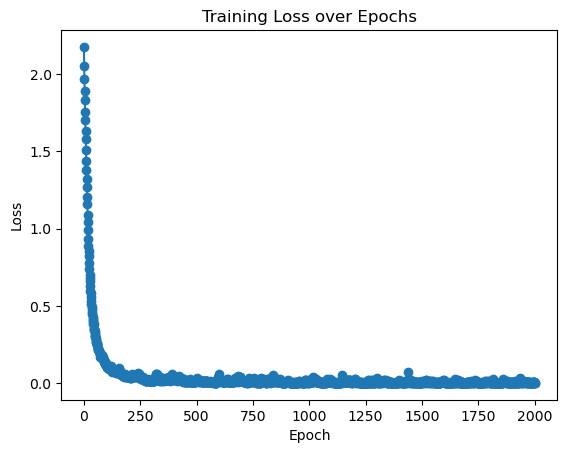

Final training loss: 0.0018792268371757247
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


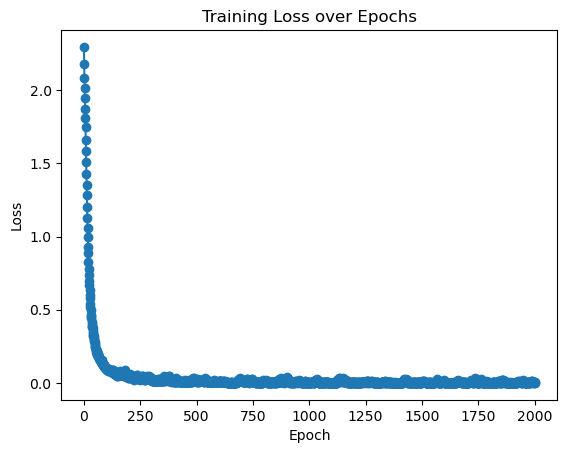

Final training loss: 0.0034962645323391548
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


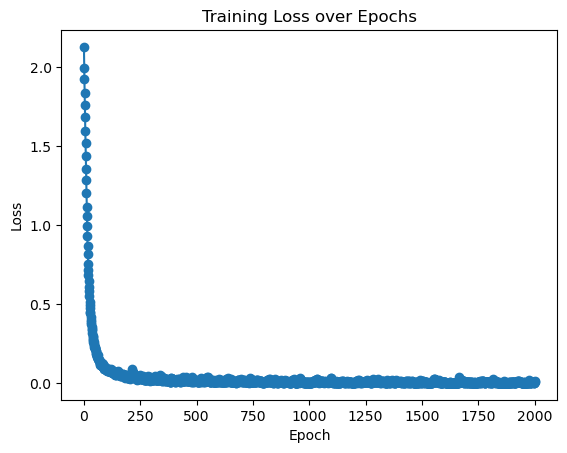

Final training loss: 0.011623998951571842
[TorchWrapper] Using device: mps


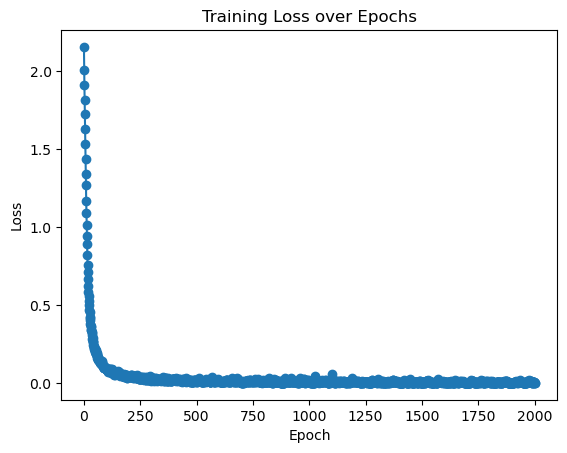

Final training loss: 0.0012647698328183744
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.29273182957393484, 'away_goals_valid_precision': 0.16992750091329062, 'away_goals_test_accuracy': 0.29699248120300753, 'away_goals_test_precision': 0.2861022749180644, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt

In [18]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    key_columns=TRAINGING_CONFIG['key_columns'],
)

/Users/tianqihuang/Documents/GitHub/betbot/src/model/experiment_utils.py:126: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


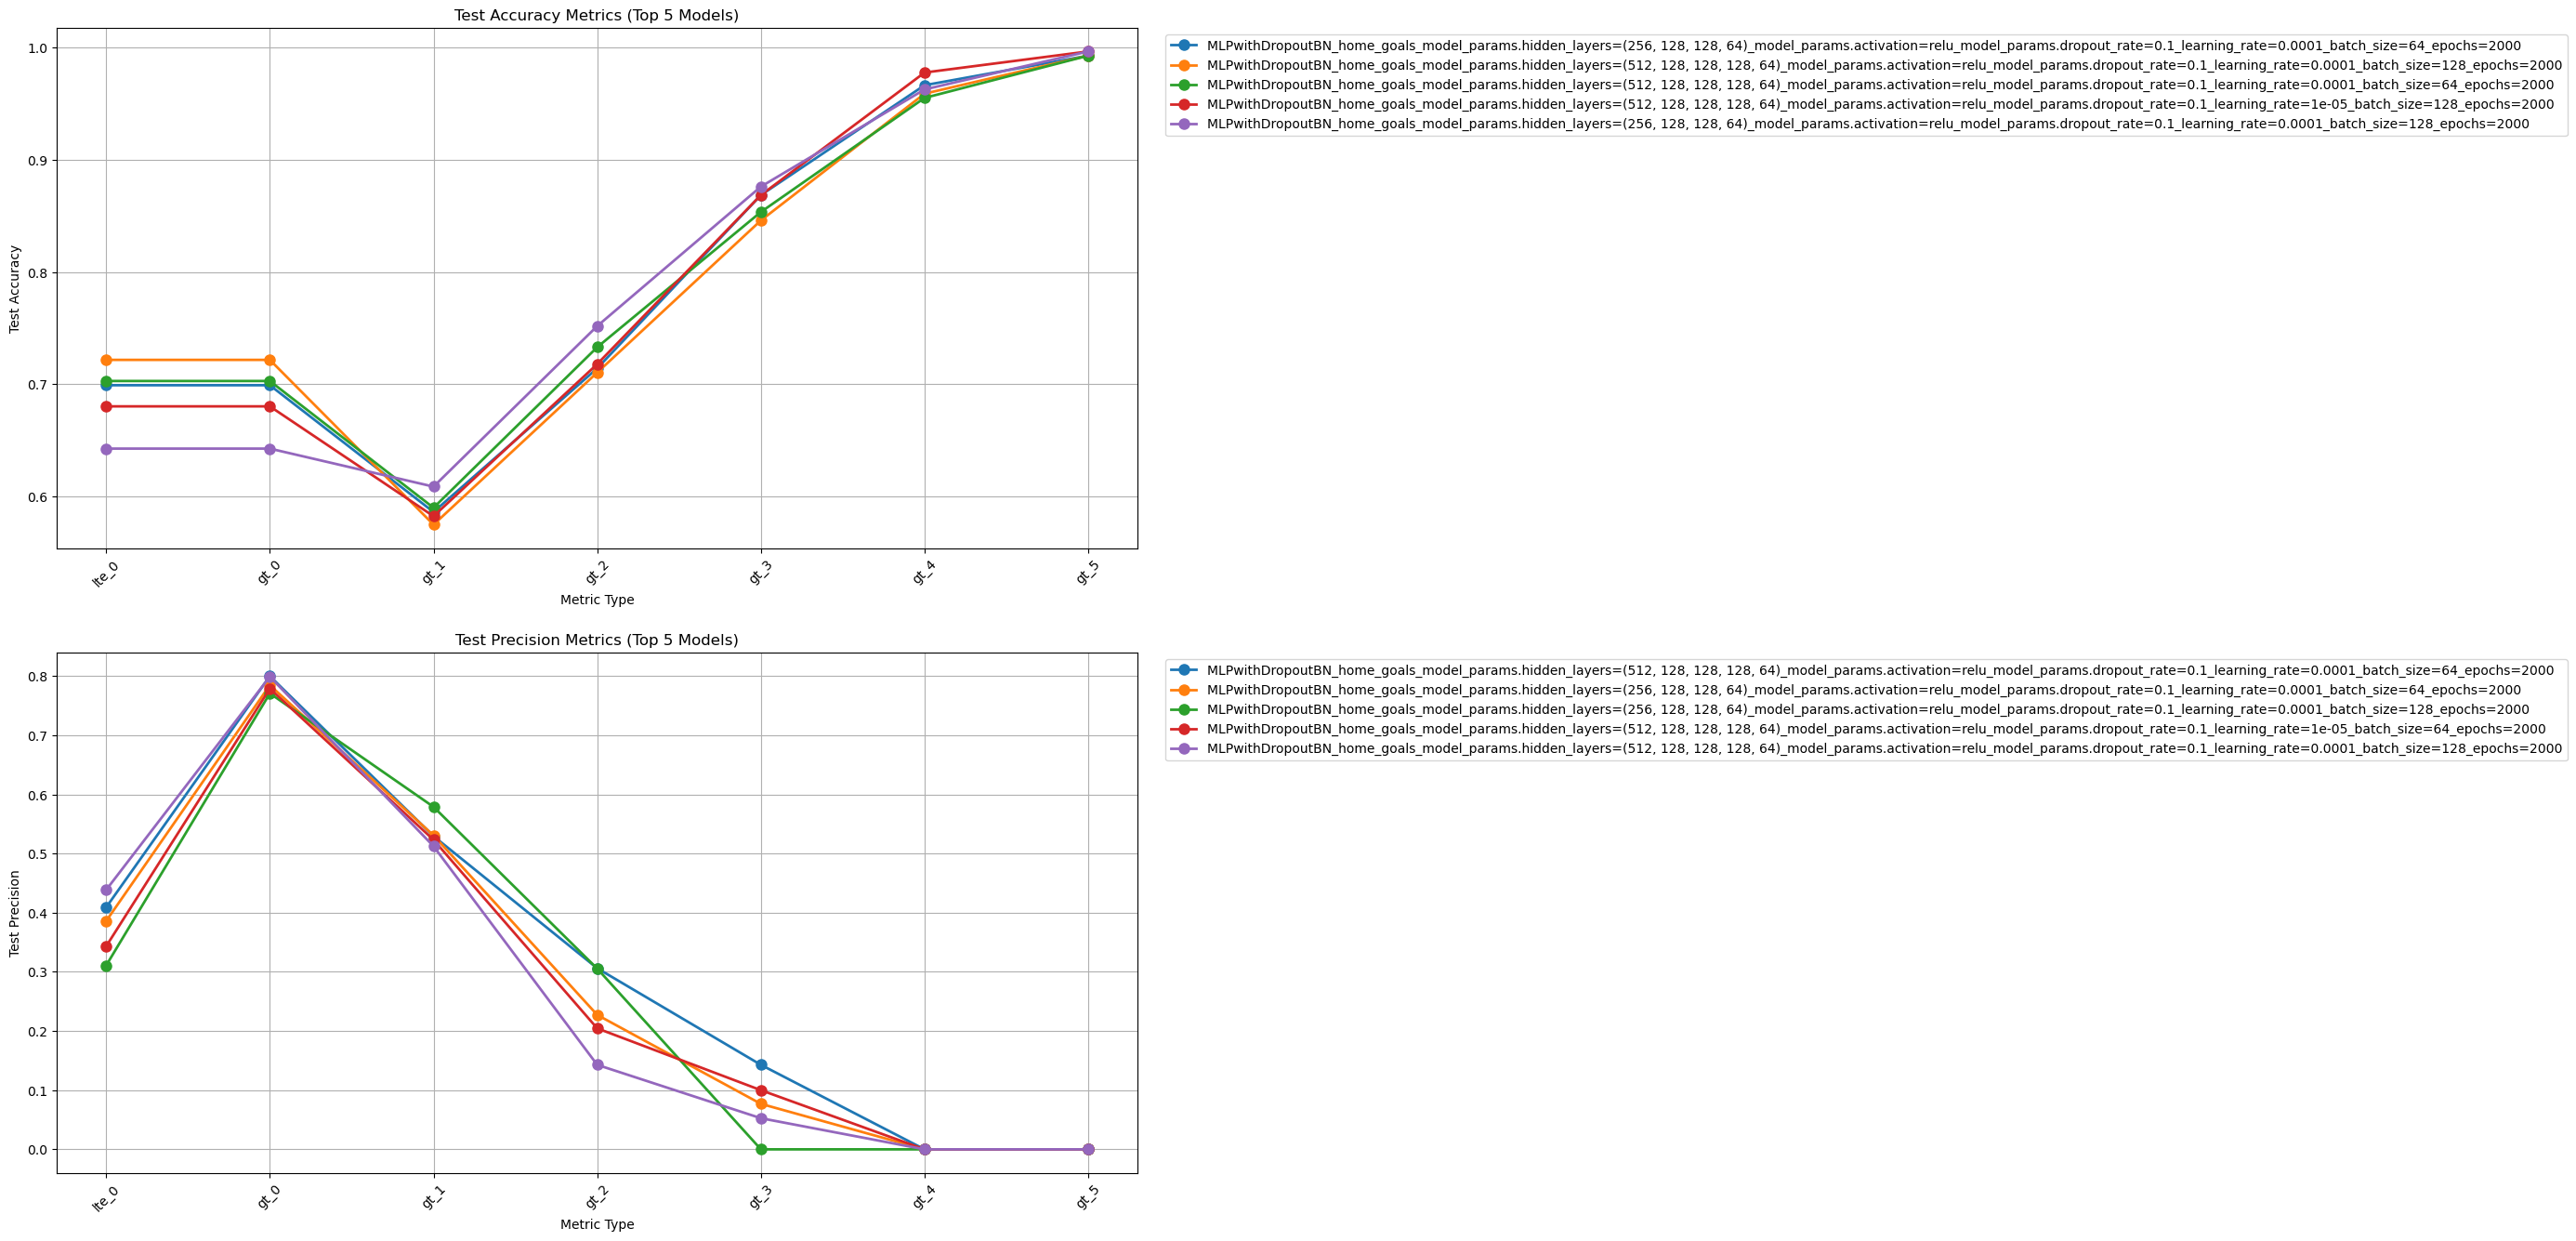

In [19]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [20]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_{'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

MlflowException: Invalid clause(s) in filter string: 'tags.mlflow.runName = 'MLPwithDropoutBN_away_goals_{'model_params.hidden_layers', '': (512, 256, 256, 128, 128), '', 'model_params.activation', '': '', 'relu', '', '', 'model_params.dropout_rate', '': 0, '', 'learning_rate', '': 1e-05, '', 'batch_size', '': 64, '', 'epochs', '': 5000}''

In [ ]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers: '(512, 256, 256, 128, 128)' and params.model_params.activation: 'relu' and params.model_params.dropout_rate: '0' and params.learning_rate: '1e-05' and params.batch_size: '64' and params.epochs: '5000'


MlflowException: Invalid clause(s) in filter string: 'params.model_params.hidden_layers', ':', ''(512, 256, 256, 128, 128)'', 'params.model_params.activation', ':', ''relu'', 'params.model_params.dropout_rate', ':', ''0'', 'params.learning_rate', ':', ''1e-05'', 'params.batch_size', ':', ''64'', 'params.epochs', ':', ''5000''